In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
telco = pd.read_csv("telco_customer_churn2.csv", engine='python')



In [3]:
print(telco.head())
print(telco.shape)
print(telco.info())
print(telco.describe(include='all'))




  customer_id  gender  senior_citizen partner DEPENDENTS   tenure  \
0  7590-VHVEG  Female               0     Yes          No       1   
1  5575-GNVDE    Male               0      No          No      34   
2  3668-QPYBK    Male               0      No          No       2   
3  7795-CFOCW    Male               0      No          No      45   
4  7795-CFOCW    Male               0      No          No      45   

  pho_ne_service  multi$ple_l@ines int#e&rnet_service onli!ne_secur^ity  ...  \
0             No  No phone service                DSL                No  ...   
1            Yes                No                DSL               Yes  ...   
2            Yes                No                DSL               Yes  ...   
3             No  No phone service                DSL               Yes  ...   
4             No  No phone service                DSL               Yes  ...   

  device_protectio+n TECH_SUP(PORT st-rea(min(g_tv streaming_movies  \
0                 No            N

In [4]:
telco.columns = telco.columns.str.strip()
telco.columns = telco.columns.str.lower()
telco.columns = telco.columns.str.replace('[^a-z0-9_]', '', regex=True)
telco.columns = telco.columns.str.replace(' ', '_')
telco.rename(columns={
    'ch_urn': 'churn',
    'pho_ne_service': 'phone_service',
    'payment_metho_d': 'payment_method'
}, inplace=True)


print(telco.columns)


Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')


In [5]:
telco = telco.dropna()
print(telco.isna().sum())
print(telco.head())

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64
  customer_id  gender  senior_citizen partner dependents  tenure  \
0  7590-VHVEG  Female               0     Yes         No       1   
1  5575-GNVDE    Male               0      No         No      34   
2  3668-QPYBK    Male               0      No         No       2   
3  7795-CFOCW    Male               0      No         No      45   
4  7795-CFOCW    Male               0      No         No      45   

  phone_service    multiple_lines internet_service online_security  ...  \
0            No  No 

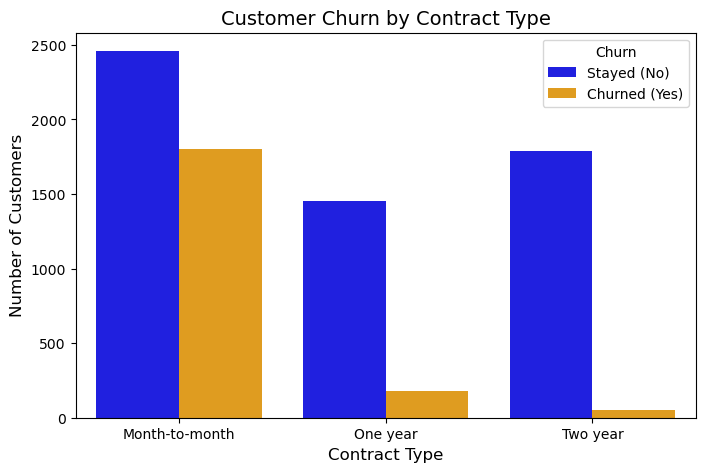

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(x='contract', hue='churn', data=telco,
              hue_order=['No', 'Yes'],
              palette={'No':'blue', 'Yes':'orange'})

plt.title("Customer Churn by Contract Type", fontsize=14)
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.legend(title="Churn", labels=['Stayed (No)', 'Churned (Yes)'], loc='upper right')

plt.show()


Churn is highest among month-to-month customers, while longer contracts retain loyalty.
Insight: Targeting short-term customers with incentives or engagement can reduce churn and boost retention.